# Cross-version comparison: original → fixed → optimized → pHash

Reads `summaries/*.json` produced by `notebooks/profile.ipynb` (run on each
hasher version), and produces:

1. Summary table (latency, throughput, memory, scaling) side-by-side.
2. Speedup table (each version vs original baseline).
3. Latency-distribution overlay.
4. Scaling-sweep overlay (per-image runtime vs N).
5. Acceptance bar auto-fill (T1, T2, C1 from JSON; A* from accuracy_benchmark.py).

This notebook is the source for **Part 1 figures and tables** of the report.
Re-run after each new version is benchmarked.

In [1]:
import sys, os, json
from pathlib import Path

_here = Path.cwd()
PROJECT_ROOT = _here.parent if _here.name == 'notebooks' else _here
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

SUMMARIES_DIR = PROJECT_ROOT / 'summaries'
FIG_DIR = PROJECT_ROOT / 'figures' / 'comparison'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Load all available summaries (graceful: ignores missing versions)
EXPECTED_VERSIONS = ['original', 'fixed', 'optimized', 'phash']
summaries = {}
for v in EXPECTED_VERSIONS:
    p = SUMMARIES_DIR / f'{v}_summary.json'
    if p.exists():
        with open(p) as f:
            summaries[v] = json.load(f)
        print(f'  loaded: {v}')
    else:
        print(f'  missing: {v} (run profile.ipynb with HASHER_NAME="{v}" to generate)')

print(f'\n{len(summaries)}/{len(EXPECTED_VERSIONS)} versions available')

  loaded: original
  missing: fixed (run profile.ipynb with HASHER_NAME="fixed" to generate)
  loaded: optimized
  missing: phash (run profile.ipynb with HASHER_NAME="phash" to generate)

2/4 versions available


## 1. Summary table — side-by-side core metrics

In [2]:
import pandas as pd

rows = []
for version, s in summaries.items():
    rows.append({
        'version': version,
        'class': s.get('hasher_class', '?'),
        'mean_ms': s['mean_s'] * 1000,
        'median_ms': s['median_s'] * 1000,
        'p95_ms': s['p95_s'] * 1000,
        'max_ms': s['max_s'] * 1000,
        'std_ms': s['std_s'] * 1000,
        'throughput_img_s': 1.0 / s['per_image_s'],
        'archive_55972_hours': s['extrapolation_full_archive_hours_1x'],
        'io_pct': s['io_split']['io_fraction'] * 100 if 'io_split' in s else None,
    })

df = pd.DataFrame(rows).set_index('version')
df.round(2)

,class,mean_ms,median_ms,p95_ms,max_ms,std_ms,throughput_img_s,archive_55972_hours,io_pct
version,,,,,,,,,
original,FINDHasher,464.08,453.48,574.67,688.81,66.74,2.15,7.22,0.43
optimized,FINDHasherOptimized,4.64,4.40,5.50,15.36,1.20,215.73,0.07,21.48


## 2. Speedup table — every version vs original baseline

If `original` is missing this section is a no-op.

In [3]:
if 'original' in summaries:
    base = summaries['original']
    speedup_rows = []
    for v, s in summaries.items():
        speedup_rows.append({
            'version': v,
            'mean_speedup': base['mean_s'] / s['mean_s'],
            'p95_speedup': base['p95_s'] / s['p95_s'],
            'throughput_speedup': s['per_image_s'] / base['per_image_s'] and (1/s['per_image_s']) / (1/base['per_image_s']),
            'archive_hours_saved': base['extrapolation_full_archive_hours_1x'] - s['extrapolation_full_archive_hours_1x'],
        })
    speedup_df = pd.DataFrame(speedup_rows).set_index('version')
    print(speedup_df.round(2))
else:
    print('No original baseline available; skipping speedup analysis.')

           mean_speedup  p95_speedup  throughput_speedup  archive_hours_saved
version                                                                      
original           1.00          1.0                1.00                 0.00
optimized        100.11        104.5              100.11                 7.14


## 3. Latency-distribution overlay

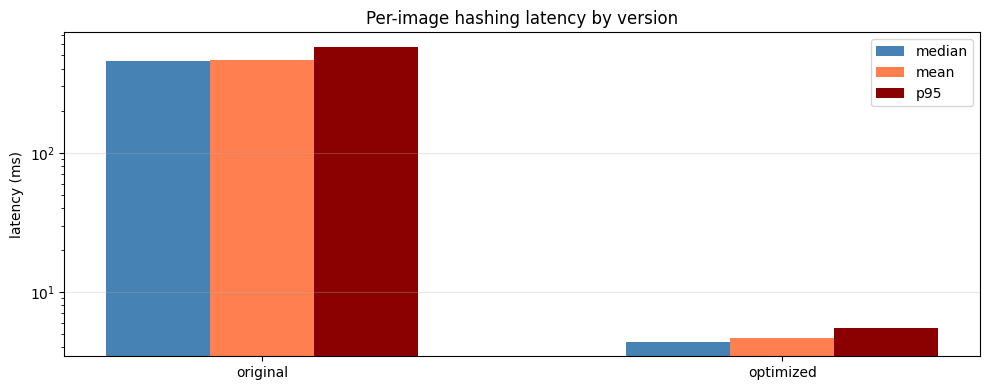

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# We don't have raw timings in JSON, but we have summary stats — show as box-style
fig, ax = plt.subplots(figsize=(10, 4))

versions = list(summaries.keys())
positions = np.arange(len(versions))
medians = [summaries[v]['median_s'] * 1000 for v in versions]
p95s    = [summaries[v]['p95_s'] * 1000 for v in versions]
means   = [summaries[v]['mean_s'] * 1000 for v in versions]
maxes   = [summaries[v]['max_s'] * 1000 for v in versions]

ax.bar(positions - 0.2, medians, width=0.2, label='median', color='steelblue')
ax.bar(positions,        means,   width=0.2, label='mean',   color='coral')
ax.bar(positions + 0.2,  p95s,    width=0.2, label='p95',    color='darkred')
ax.set_xticks(positions)
ax.set_xticklabels(versions)
ax.set_ylabel('latency (ms)')
ax.set_title('Per-image hashing latency by version')
ax.legend()
ax.grid(alpha=0.3, axis='y')
ax.set_yscale('log')   # log scale because baseline vs optimized may differ 20x
fig.tight_layout()
fig.savefig(FIG_DIR / 'comp_latency.png', dpi=150)
plt.show()

## 4. Scaling-sweep overlay — per-image runtime vs N

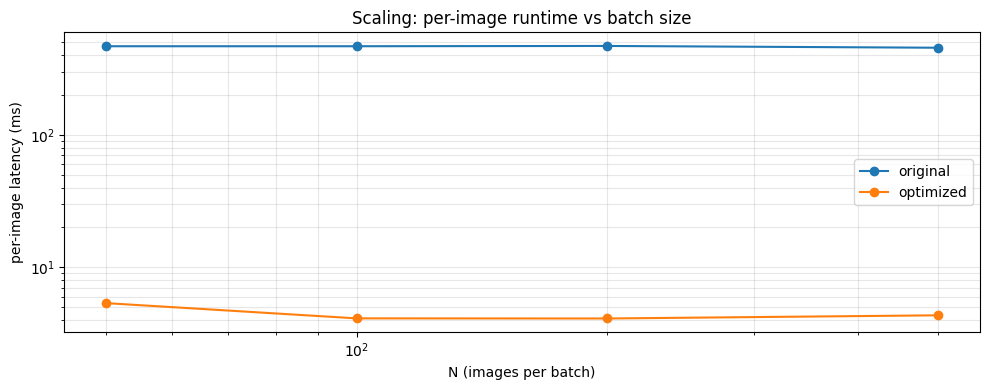

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
for v, s in summaries.items():
    if 'scaling' not in s or not s['scaling']:
        continue
    ns = [r['n'] for r in s['scaling']]
    per_img = [r['per_image_s'] * 1000 for r in s['scaling']]
    ax.plot(ns, per_img, 'o-', label=v)
ax.set_xlabel('N (images per batch)')
ax.set_ylabel('per-image latency (ms)')
ax.set_title('Scaling: per-image runtime vs batch size')
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(alpha=0.3, which='both')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'comp_scaling.png', dpi=150)
plt.show()

## 5. Acceptance bar auto-fill (T1, T2, T3, C1, C2)

These rows can be pasted directly into `evaluation_criteria.md` Section 6.

C2 cost calc: AWS Lambda 512 MB pricing — `0.0000166667 $/GB-sec * 0.5 GB * latency_s + 0.20 $/M invocations`.

In [6]:
def cost_per_million(latency_s, memory_gb=0.5):
    compute = 0.0000166667 * memory_gb * latency_s * 1_000_000
    invocations = 0.20
    return compute + invocations

acceptance_rows = []
for v, s in summaries.items():
    p95_ms = s['p95_s'] * 1000
    throughput = 1.0 / s['per_image_s']
    archive_min = s['extrapolation_full_archive_hours_1x'] * 60
    cost = cost_per_million(s['mean_s'])
    acceptance_rows.append({
        'version': v,
        'T1 latency p95 (ms)': round(p95_ms, 1),
        'T2 throughput (img/s)': round(throughput, 1),
        'C1 archive (min)': round(archive_min, 1),
        'C2 cost ($/M @ 512MB)': round(cost, 2),
    })
print(pd.DataFrame(acceptance_rows).set_index('version').to_markdown())

| version   |   T1 latency p95 (ms) |   T2 throughput (img/s) |   C1 archive (min) |   C2 cost ($/M @ 512MB) |
|:----------|----------------------:|------------------------:|-------------------:|------------------------:|
| original  |                 574.7 |                     2.2 |              432.9 |                    4.07 |
| optimized |                   5.5 |                   215.7 |                4.3 |                    0.24 |


## 6. Export this comparison as HTML

Generates `reports/comparison/compare_report.html` — paste into Part 1 PDF or share with reviewer.

In [7]:
import subprocess

report_dir = PROJECT_ROOT / 'reports' / 'comparison'
report_dir.mkdir(parents=True, exist_ok=True)

result = subprocess.run(
    [
        'jupyter', 'nbconvert', '--to', 'html',
        str(PROJECT_ROOT / 'notebooks' / 'compare_versions.ipynb'),
        '--output-dir', str(report_dir),
        '--output', 'compare_report.html',
    ],
    capture_output=True, text=True,
)
if result.returncode != 0:
    print('ERROR:', result.stderr)
else:
    print(result.stdout.strip() or 'OK')
    print(f'HTML report -> {(report_dir / "compare_report.html").relative_to(PROJECT_ROOT)}')

OK
HTML report -> reports/comparison/compare_report.html
